# End-to-end full-image pipeline preview: ENetOriginal -> tile -> SmallRefinementENet -> stitch

Unlike `preview_508_results.ipynb` (which evaluates on Dataset508's own
pre-cut 96x96 patch categories), this notebook runs the *actual deployment
pipeline* on 5 random full 512x512 images from Dataset501_ARCADE's held-out
test split:

1. Run `nnUNetTrainerENetOriginal`'s trained network on the full image ->
   4-class softmax -> vessel probability (`1 - P(background)`).
2. Threshold at 0.5 for the "passthrough" first-pass mask.
3. Tile both the raw image and the probability map into a 96x96 grid
   (zero-padded up to 576x576 = 6x6 tiles, cropped back after stitching).
4. Run `nnUNetTrainerSmallRefinementENet` (trained on
   Dataset508_ARCADE_refinement_hard) on every tile independently, each
   channel z-score normalized per-tile (matching training).
5. Stitch the refined tiles back into a full-image prediction.
6. Compare whole-image Dice: passthrough vs. GT, and stitched-refined vs.
   GT, plus a visual overlay/blend of each against GT on top of the raw
   image.

This is the more honest test of whether the refinement net is actually
useful in practice -- Dataset508's patches were placed with specific intent
(centered on discontinuities, etc.), which isn't how a real deployment would
feed it patches. Tiling a full image on a plain grid and stitching is what
actually happens if this network is used as a second-stage post-processor.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from PIL import Image
from scipy import ndimage as ndi

# Same numpy/torch checkpoint-loading fix used in every other preview
# notebook this session -- checkpoints trained under numpy>=2.0 fail to
# load under numpy 1.26.4's torch.load(..., weights_only=False).
import numpy.core.multiarray as _ma

_orig_scalar = _ma.scalar


def _patched_scalar(dtype, obj):
    if not isinstance(dtype, np.dtype):
        try:
            dtype = np.dtype(dtype.type) if hasattr(dtype, "type") else np.dtype(dtype)
        except Exception as e:
            raise TypeError(f"could not coerce {dtype!r} to np.dtype") from e
    return _orig_scalar(dtype, obj)


_ma.scalar = _patched_scalar


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "lightm-unet").exists() and (candidate / "data").exists():
            return candidate
    return start


REPO_ROOT = _find_repo_root(Path.cwd())
PACKAGE_ROOT = REPO_ROOT / "lightm-unet"
sys.path.insert(0, str(PACKAGE_ROOT))
from nnunetv2.nets.ENet import ENet  # noqa: E402
from nnunetv2.nets.SmallRefinementENet import SmallRefinementENet  # noqa: E402

NNUNET_RESULTS = REPO_ROOT / "data" / "nnUNET_results"
SOURCE_DIR = REPO_ROOT / "data" / "nnUNet_raw" / "Dataset501_ARCADE"
IMAGES_TS_DIR = SOURCE_DIR / "imagesTs"
LABELS_TS_DIR = SOURCE_DIR / "labelsTs"

ENETORIGINAL_CKPT = NNUNET_RESULTS / "Dataset501_ARCADE" / "nnUNetTrainerENetOriginal__nnUNetPlans__2d" / "fold_0" / "checkpoint_best.pth"
REFINEMENT_CKPT = NNUNET_RESULTS / "Dataset508_ARCADE_refinement_hard" / "nnUNetTrainerSmallRefinementENet__nnUNetPlans__2d" / "fold_0" / "checkpoint_best.pth"

METRICS_DIR = REPO_ROOT / "analysis" / "508_ARCADE_refinement_hard" / "results_full_image"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# ENetOriginal: default ENET_CHANNELS ("20,72,144,72,20"), 4 classes
# (background/LAD/RCA/LCX per Dataset501_ARCADE/dataset.json) -- no override
# found in this checkpoint's debug.json, so using nnUNetTrainerENet.py's
# default. SmallRefinementENet: same defaults as every other notebook this
# session (stem=8, stage=32).
ENET_CHANNELS = (20, 72, 144, 72, 20)
STEM_CHANNELS = 8
STAGE_CHANNELS = 32
THRESHOLD = 0.5
PATCH_SIZE = 96
N_IMAGES = 5
SEED = 0

# Sliding-window overlap and vessel-targeting, added after the first
# non-overlapping-grid pass showed the refinement net hallucinating small FP
# blobs across background tiles it never saw anything like during training
# (Dataset508's patches were all specifically sampled -- discontinuity-
# centered, FPS-covered, or empty/FP-region-sampled -- never a plain grid
# cut of arbitrary background). Two changes: (1) OVERLAP_FRAC gives
# neighboring tiles shared context and lets overlapping predictions
# average out single-tile artifacts, rather than each tile deciding in
# total isolation with a hard seam at its border; (2) VESSEL_DILATION_PX
# skips refinement entirely on tiles with no predicted vessel anywhere
# nearby (falling back to the untouched passthrough probability there)
# instead of running the net blindly over 100% of the image -- most of a
# real image is confidently-empty background the net was never asked to
# "improve" and has no business touching.
OVERLAP_FRAC = 0.2   # 20% -- within the requested 10-25% range
VESSEL_DILATION_PX = 32  # ~= widest vessel radius seen in ARCADE (p99 ~20-24px) plus margin

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Repo root         :", REPO_ROOT)
print("ENetOriginal ckpt  :", ENETORIGINAL_CKPT, ENETORIGINAL_CKPT.exists())
print("Refinement ckpt    :", REFINEMENT_CKPT, REFINEMENT_CKPT.exists())
print("imagesTs count     :", len(list(IMAGES_TS_DIR.glob("*_0000.png"))))
print("Device             :", DEVICE)
print(f"OVERLAP_FRAC={OVERLAP_FRAC}, VESSEL_DILATION_PX={VESSEL_DILATION_PX}")

Repo root         : /workspace/LightM-UNet
ENetOriginal ckpt  : /workspace/LightM-UNet/data/nnUNET_results/Dataset501_ARCADE/nnUNetTrainerENetOriginal__nnUNetPlans__2d/fold_0/checkpoint_best.pth True
Refinement ckpt    : /workspace/LightM-UNet/data/nnUNET_results/Dataset508_ARCADE_refinement_hard/nnUNetTrainerSmallRefinementENet__nnUNetPlans__2d/fold_0/checkpoint_best.pth True
imagesTs count     : 300
Device             : cuda
OVERLAP_FRAC=0.2, VESSEL_DILATION_PX=32


## Load both models

In [2]:
def load_checkpoint_into(model: torch.nn.Module, path: Path) -> dict:
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["network_weights"])
    return checkpoint


enet_model = ENet(in_channels=1, out_channels=4, channels=ENET_CHANNELS)
enet_checkpoint = load_checkpoint_into(enet_model, ENETORIGINAL_CKPT)
enet_model = enet_model.to(DEVICE).eval()

refinement_model = SmallRefinementENet(stem_channels=STEM_CHANNELS, stage_channels=STAGE_CHANNELS)
refinement_checkpoint = load_checkpoint_into(refinement_model, REFINEMENT_CKPT)
refinement_model = refinement_model.to(DEVICE).eval()

print(f"ENetOriginal: epoch {enet_checkpoint.get('current_epoch')}, "
      f"{sum(p.numel() for p in enet_model.parameters()):,} params")
print(f"SmallRefinementENet: epoch {refinement_checkpoint.get('current_epoch')}, "
      f"{sum(p.numel() for p in refinement_model.parameters()):,} params")

ENetOriginal: epoch 150, 466,456 params
SmallRefinementENet: epoch 113, 31,113 params


## Pipeline: ENetOriginal -> vessel-targeted overlapping tiles -> SmallRefinementENet -> blended stitch

Two changes from the first (naive grid) pass, both aimed at the FP-blob
artifacts that pass showed in background regions:

- **Vessel targeting**: the passthrough mask is dilated by
  `VESSEL_DILATION_PX` and only tiles that overlap the dilated region get
  fed through the refinement net at all. Tiles with no vessel anywhere
  nearby keep the original, untouched passthrough probability -- the net
  never gets a chance to hallucinate something in confidently-empty space
  it was never asked to look at.
- **Overlapping stride + averaging**: tiles are stepped at
  `PATCH_SIZE * (1 - OVERLAP_FRAC)` instead of `PATCH_SIZE` (non-
  overlapping), nnU-Net-sliding-window style -- the last step in each axis
  is clamped so tiling still reaches exactly to the image edge. Overlapping
  tiles' predictions are averaged per-pixel, which should smooth out
  single-tile boundary artifacts instead of leaving a hard seam.

In [3]:
def load_gray(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)


def load_gt(path: Path) -> np.ndarray:
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr > 0  # any class (LAD/RCA/LCX) > 0 = vessel


def zscore_normalize(image: np.ndarray) -> np.ndarray:
    mean = image.mean()
    std = image.std()
    return (image - mean) / max(std, 1e-8)


def compute_starts(size: int, patch_size: int, stride: int) -> list[int]:
    """Sliding-window tile start positions covering [0, size], nnU-Net
    style -- steps at `stride`, but the final step is clamped to
    size - patch_size so the last tile always reaches exactly to the far
    edge. No padding needed (unlike the first non-overlapping-grid pass):
    edge tiles just overlap their neighbor more instead of reading
    zero-padded content the network never saw in training."""
    if size <= patch_size:
        return [0]
    starts = list(range(0, size - patch_size + 1, stride))
    if starts[-1] != size - patch_size:
        starts.append(size - patch_size)
    return starts


@torch.no_grad()
def run_enetoriginal(raw: np.ndarray) -> np.ndarray:
    """Full-image forward pass. Returns vessel probability (1 - P(background)), shape (H, W), [0, 1]."""
    raw_n = zscore_normalize(raw)
    x = torch.from_numpy(raw_n).float()[None, None].to(DEVICE)  # 1,1,H,W
    logits = enet_model(x)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()  # 4,H,W
    return 1.0 - probs[0]


@torch.no_grad()
def run_refinement_tiled(
    raw: np.ndarray, vessel_prob: np.ndarray,
    overlap_frac: float = OVERLAP_FRAC, dilation_px: int = VESSEL_DILATION_PX,
) -> tuple[np.ndarray, int, int]:
    """Vessel-targeted, overlapping sliding-window refinement. Returns
    (refined vessel probability, n_tiles_refined, n_tiles_total)."""
    h, w = raw.shape
    stride = max(1, int(round(PATCH_SIZE * (1 - overlap_frac))))
    y_starts = compute_starts(h, PATCH_SIZE, stride)
    x_starts = compute_starts(w, PATCH_SIZE, stride)

    passthrough_mask = vessel_prob > THRESHOLD
    dilated_mask = ndi.binary_dilation(passthrough_mask, iterations=dilation_px) if dilation_px > 0 else passthrough_mask

    prob_sum = np.zeros_like(vessel_prob, dtype=np.float32)
    weight_sum = np.zeros_like(vessel_prob, dtype=np.float32)
    n_refined = 0
    n_total = 0

    for y0 in y_starts:
        for x0 in x_starts:
            n_total += 1
            y1, x1 = y0 + PATCH_SIZE, x0 + PATCH_SIZE
            if not dilated_mask[y0:y1, x0:x1].any():
                continue  # no vessel anywhere nearby -- leave to the passthrough fallback below

            n_refined += 1
            raw_tile = raw[y0:y1, x0:x1]
            prob_tile = vessel_prob[y0:y1, x0:x1]

            raw_n = zscore_normalize(raw_tile)
            prob_n = zscore_normalize(prob_tile * 255.0)  # same 0-255 scale used at train time

            x_in = torch.stack(
                [torch.from_numpy(raw_n).float(), torch.from_numpy(prob_n).float()], dim=0,
            )[None].to(DEVICE)
            logits = refinement_model(x_in)
            refined_tile = torch.sigmoid(logits)[0, 0].cpu().numpy()

            prob_sum[y0:y1, x0:x1] += refined_tile
            weight_sum[y0:y1, x0:x1] += 1.0

    # Where covered by at least one refined tile: average of overlapping
    # predictions. Everywhere else (no vessel nearby, never refined):
    # untouched passthrough probability.
    stitched = np.where(weight_sum > 0, prob_sum / np.maximum(weight_sum, 1e-8), vessel_prob)
    return stitched, n_refined, n_total


def dice_score(gt: np.ndarray, pred: np.ndarray) -> float:
    tp = int((gt & pred).sum())
    fp = int((~gt & pred).sum())
    fn = int((gt & ~pred).sum())
    return (2 * tp) / (2 * tp + fp + fn + 1e-8)

## Run on 5 random test images, compute Dice

In [4]:
rng = np.random.default_rng(SEED)
img_files = sorted(IMAGES_TS_DIR.glob("*_0000.png"))
chosen = rng.choice(len(img_files), size=N_IMAGES, replace=False)

results = []
cases = []
for i in chosen:
    img_path = img_files[i]
    case_id = img_path.stem[: -len("_0000")]
    gt_path = LABELS_TS_DIR / f"{case_id}.png"

    raw = load_gray(img_path)
    gt = load_gt(gt_path)

    vessel_prob = run_enetoriginal(raw)
    passthrough_pred = vessel_prob > THRESHOLD

    refined_prob, n_refined, n_total = run_refinement_tiled(raw, vessel_prob)
    refined_pred = refined_prob > THRESHOLD

    dice_passthrough = dice_score(gt, passthrough_pred)
    dice_refined = dice_score(gt, refined_pred)

    results.append({
        "case_id": case_id,
        "passthrough_dice": dice_passthrough,
        "refined_dice": dice_refined,
        "delta": dice_refined - dice_passthrough,
        "tiles_refined": n_refined,
        "tiles_total": n_total,
    })
    cases.append({
        "case_id": case_id, "raw": raw, "gt": gt, "vessel_prob": vessel_prob,
        "passthrough_pred": passthrough_pred, "refined_prob": refined_prob, "refined_pred": refined_pred,
    })
    print(f"{case_id}: passthrough dice={dice_passthrough:.4f}  refined dice={dice_refined:.4f}  "
          f"delta={dice_refined - dice_passthrough:+.4f}  tiles_refined={n_refined}/{n_total}")

results_df = pd.DataFrame(results)
results_df.to_csv(METRICS_DIR / "full_image_dice_v2_overlap_targeted.csv", index=False)
print()
display(results_df)
print("\nMean passthrough dice:", results_df["passthrough_dice"].mean())
print("Mean refined dice    :", results_df["refined_dice"].mean())

test_271: passthrough dice=0.8876  refined dice=0.8883  delta=+0.0008  tiles_refined=16/49


test_238: passthrough dice=0.7699  refined dice=0.6846  delta=-0.0853  tiles_refined=23/49


test_173: passthrough dice=0.7886  refined dice=0.7532  delta=-0.0354  tiles_refined=23/49


test_184: passthrough dice=0.8850  refined dice=0.8647  delta=-0.0203  tiles_refined=27/49


test_56: passthrough dice=0.6819  refined dice=0.6097  delta=-0.0723  tiles_refined=28/49



,case_id,passthrough_dice,refined_dice,delta,tiles_refined,tiles_total
0,test_271,0.887553,0.888321,0.000768,16,49
1,test_238,0.769933,0.684612,-0.085321,23,49
2,test_173,0.788567,0.753167,-0.035400,23,49
3,test_184,0.885038,0.864715,-0.020323,27,49
4,test_56,0.681937,0.609682,-0.072255,28,49



Mean passthrough dice: 0.8026057011678184
Mean refined dice    : 0.7600995754122575


## Visualize: raw / probability map / passthrough / refined / GT, plus overlay blends

Overlay convention (blended on top of the grayscale raw image): green = true
positive, red = false negative (missed vessel), blue = false positive
(hallucinated vessel). A "better" overlay has more green, less red/blue.

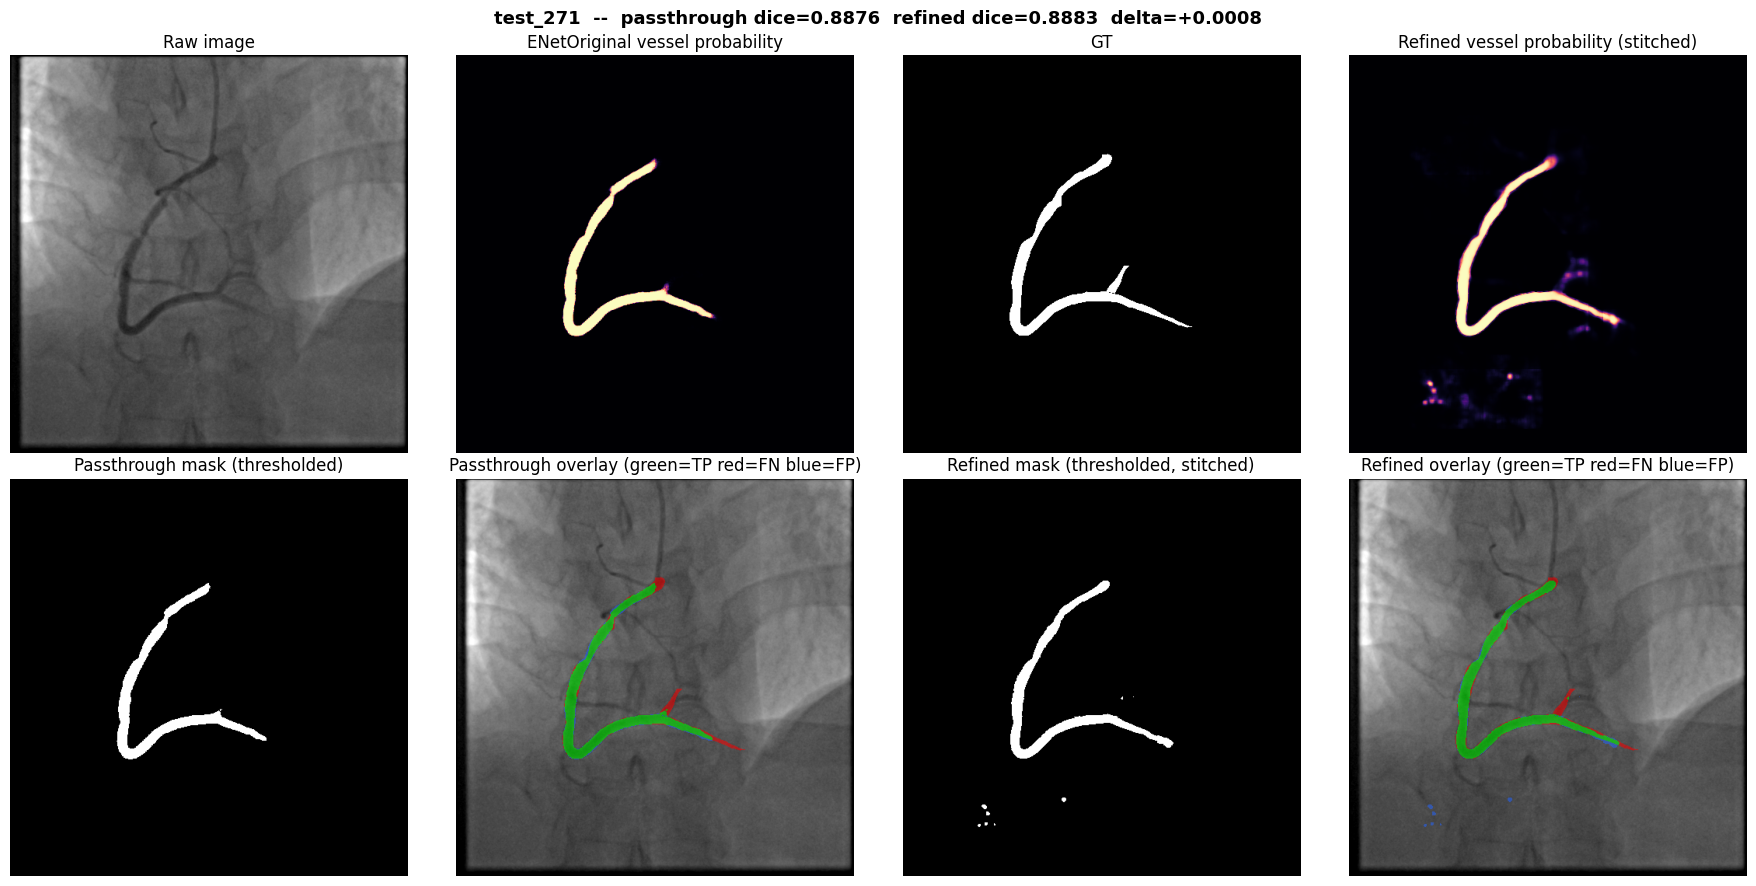

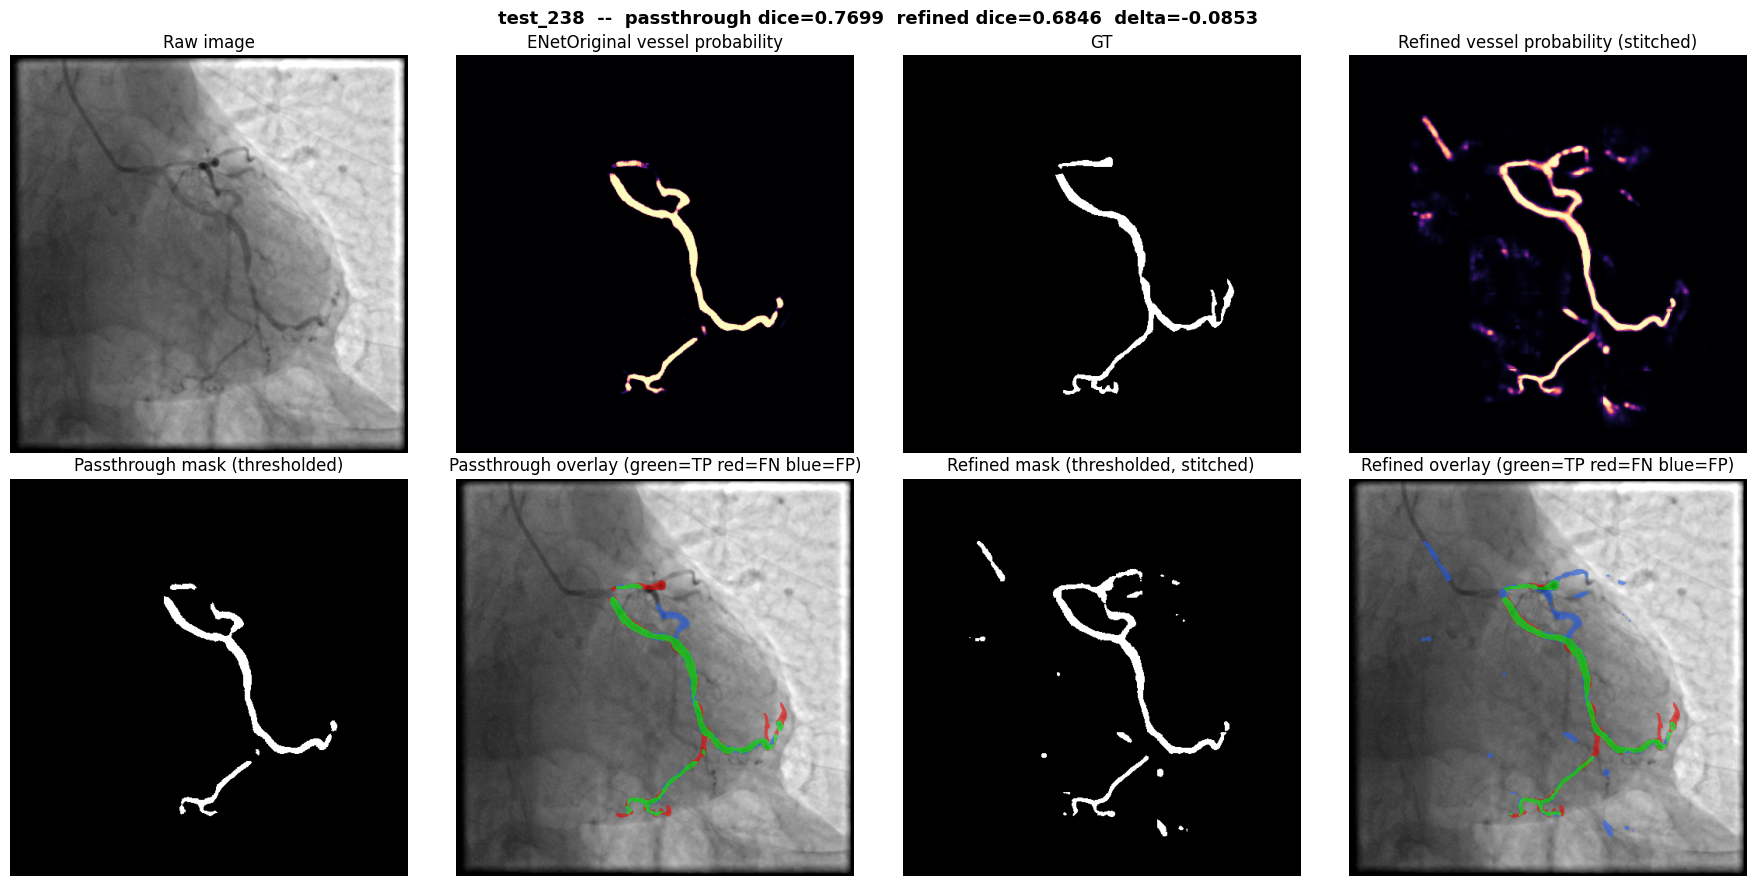

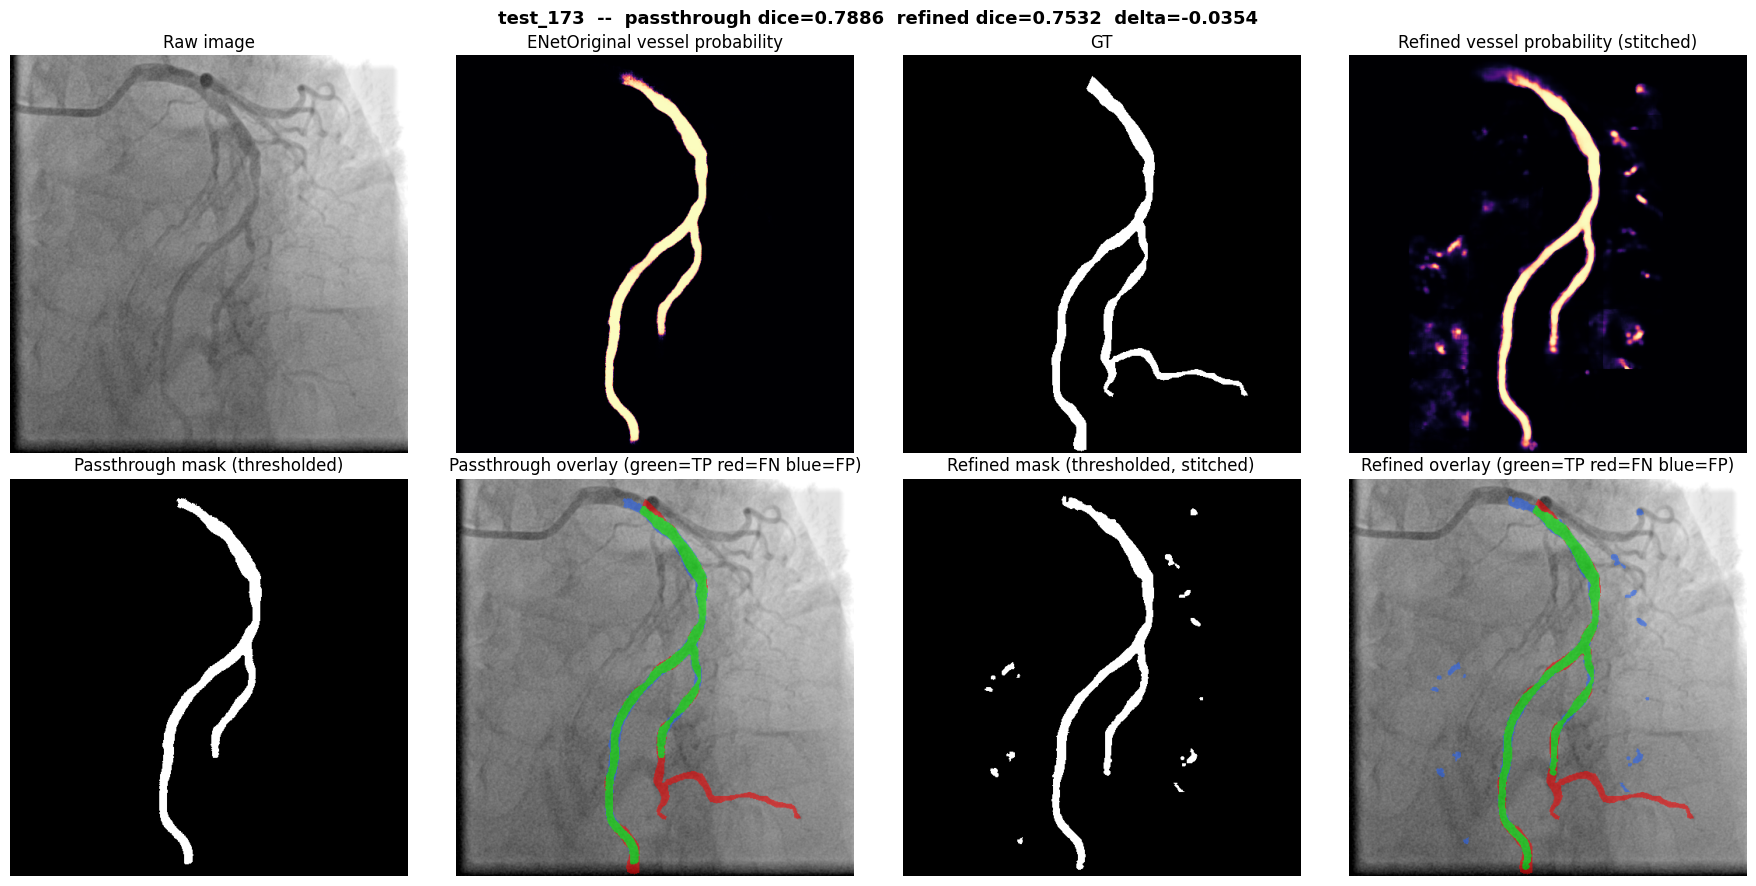

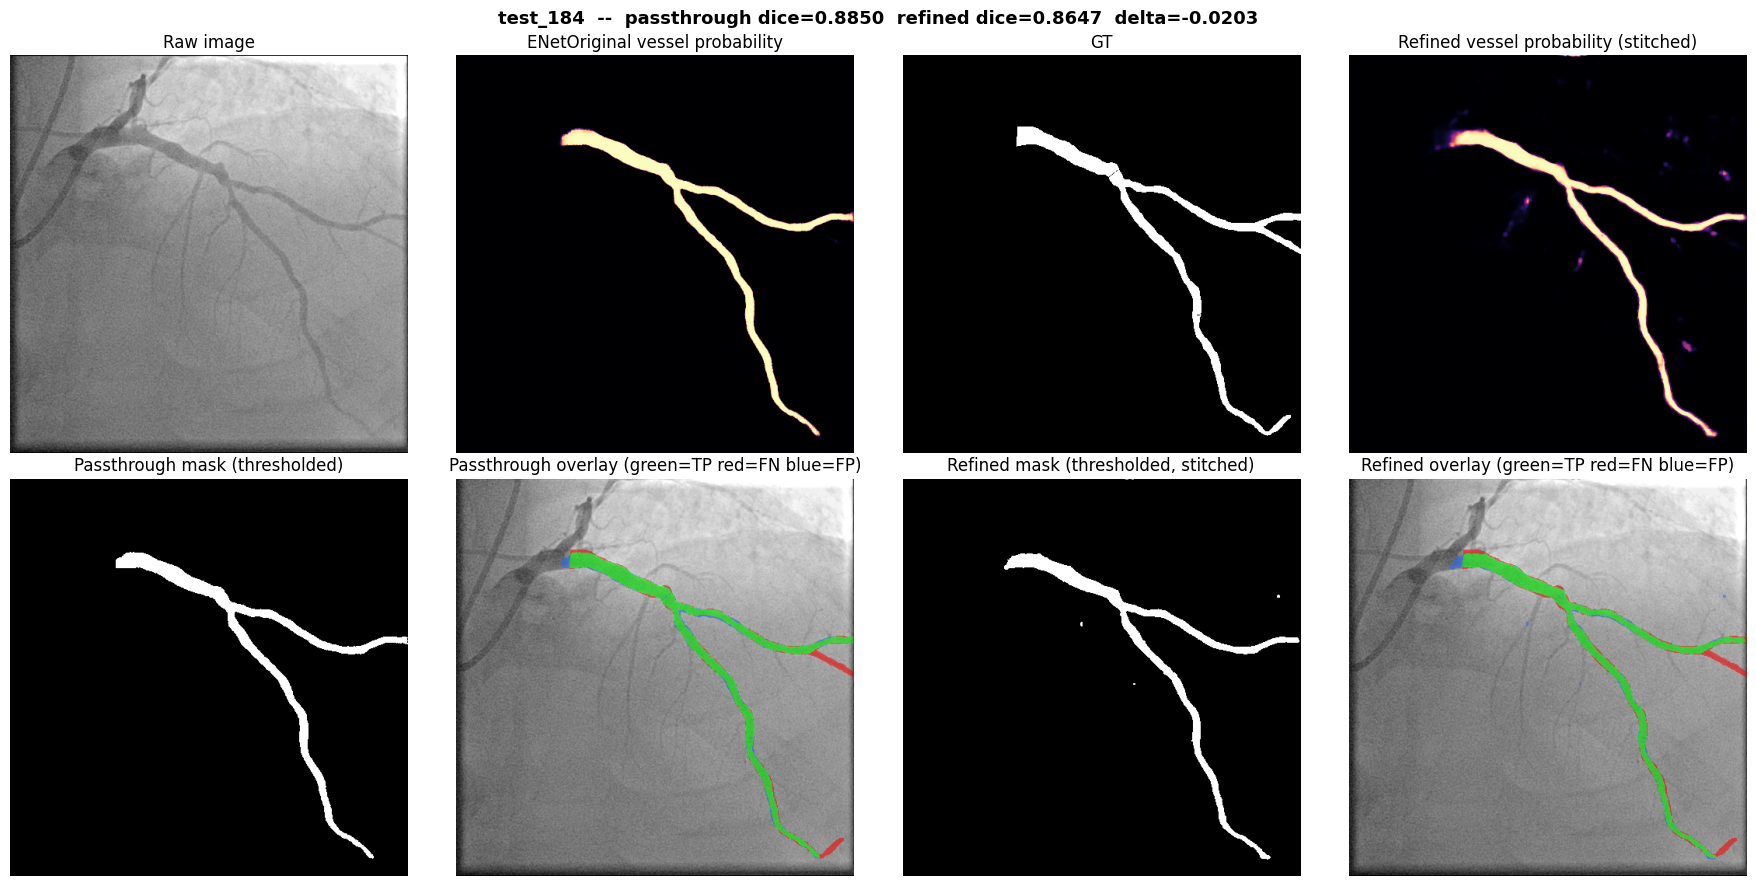

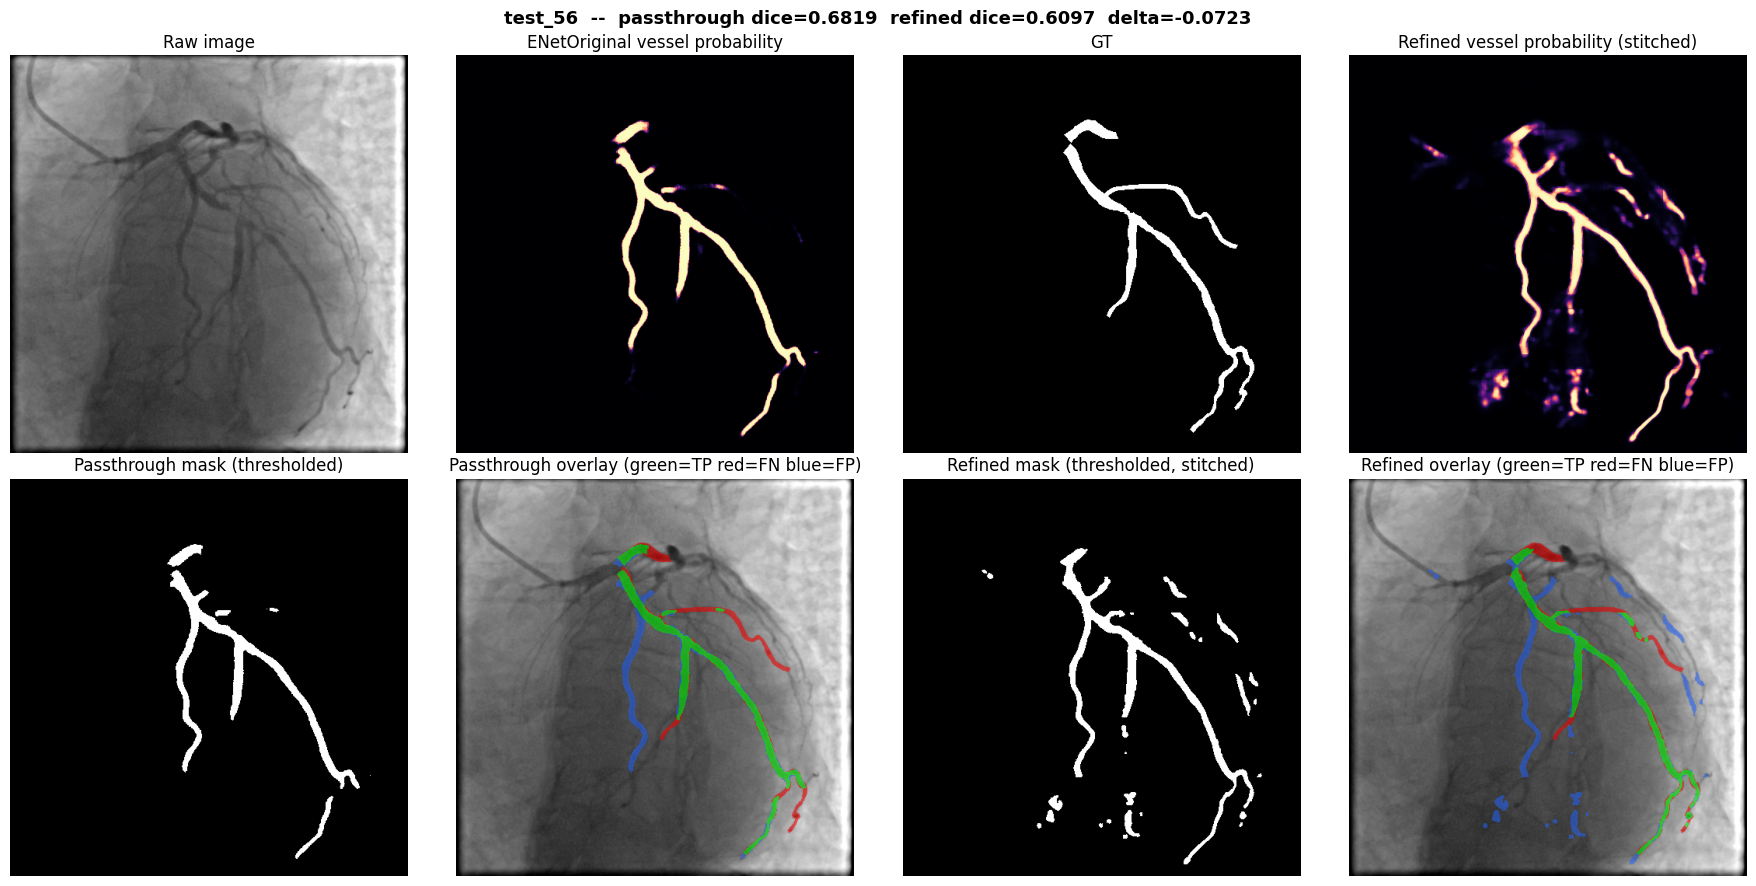

In [5]:
def make_overlay(raw: np.ndarray, gt: np.ndarray, pred: np.ndarray, alpha: float = 0.55) -> np.ndarray:
    """RGB blend: grayscale raw image + green=TP, red=FN, blue=FP."""
    base = raw / 255.0
    rgb = np.stack([base, base, base], axis=-1)

    tp = gt & pred
    fn = gt & ~pred
    fp = ~gt & pred

    color = np.zeros_like(rgb)
    color[tp] = [0.0, 1.0, 0.0]
    color[fn] = [1.0, 0.0, 0.0]
    color[fp] = [0.15, 0.4, 1.0]

    mask_any = tp | fn | fp
    blended = rgb.copy()
    blended[mask_any] = (1 - alpha) * rgb[mask_any] + alpha * color[mask_any]
    return np.clip(blended, 0, 1)


for case in cases:
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    axes[0, 0].imshow(case["raw"], cmap="gray")
    axes[0, 0].set_title("Raw image")
    axes[0, 1].imshow(case["vessel_prob"], cmap="magma", vmin=0, vmax=1)
    axes[0, 1].set_title("ENetOriginal vessel probability")
    axes[0, 2].imshow(case["gt"], cmap="gray")
    axes[0, 2].set_title("GT")
    axes[0, 3].imshow(case["refined_prob"], cmap="magma", vmin=0, vmax=1)
    axes[0, 3].set_title("Refined vessel probability (stitched)")

    axes[1, 0].imshow(case["passthrough_pred"], cmap="gray")
    axes[1, 0].set_title("Passthrough mask (thresholded)")
    axes[1, 1].imshow(make_overlay(case["raw"], case["gt"], case["passthrough_pred"]))
    axes[1, 1].set_title("Passthrough overlay (green=TP red=FN blue=FP)")
    axes[1, 2].imshow(case["refined_pred"], cmap="gray")
    axes[1, 2].set_title("Refined mask (thresholded, stitched)")
    axes[1, 3].imshow(make_overlay(case["raw"], case["gt"], case["refined_pred"]))
    axes[1, 3].set_title("Refined overlay (green=TP red=FN blue=FP)")

    for ax in axes.ravel():
        ax.axis("off")

    row = results_df[results_df["case_id"] == case["case_id"]].iloc[0]
    fig.suptitle(
        f"{case['case_id']}  --  passthrough dice={row['passthrough_dice']:.4f}  "
        f"refined dice={row['refined_dice']:.4f}  delta={row['delta']:+.4f}",
        fontweight="bold", fontsize=13,
    )
    plt.tight_layout()
    fig.savefig(METRICS_DIR / f"{case['case_id']}_full_image_panel.png", dpi=130, bbox_inches="tight")
    plt.show()

---

# Experiment: iterative, discontinuity-targeted refinement (no GT involved)

The overlap+vessel-dilation pass above still touches a lot of legitimate
vessel-adjacent territory it doesn't need to (test_56's spurious blob
fragments). This experiment targets much more narrowly, the same way
Dataset508's own `discont` training patches were placed -- centered
directly on a detected discontinuity, not a generic dilated neighborhood:

1. Run ENetOriginal -> initial vessel probability -> threshold -> binary prediction.
2. **Skeletonize the current binary prediction** and find internal skeleton
   endpoints (degree-1 skeleton pixels, excluding ones near the image
   border -- those are just where the vessel exits the field of view, not
   a real discontinuity). At inference time there's no GT to compare
   against, so this is a *self-referential* topology heuristic: an internal
   dead-end in the predicted vessel's own skeleton is a strong sign
   something dropped out there.
3. For each candidate endpoint, cut a 96x96 patch centered on it (same
   placement convention `discontinuity_boxes` used at training time) and
   run `SmallRefinementENet` on just that patch, updating the probability
   map there (overlapping patches averaged).
4. **Repeat**: re-skeletonize the *updated* prediction, find whatever
   endpoints remain (some should have closed up; new ones may appear
   elsewhere), refine again. `NUM_ITERATIONS` is parameterizable -- results
   shown for 1, 2, and 3 passes.

GT is only used afterward, to score each iteration's Dice -- never inside
the refinement loop itself, so this whole procedure is realistic for actual
deployment (no ground truth required at inference time).

In [6]:
from skimage.morphology import skeletonize

NUM_ITERATIONS = 3
BORDER_MARGIN = 12       # skeleton endpoints closer than this to the image edge are ignored
MAX_CANDIDATES_PER_ITER = 40  # safety cap in case a bad prediction is extremely fragmented


def skeleton_degree(skel: np.ndarray) -> np.ndarray:
    kernel = np.ones((3, 3), dtype=int)
    neighbor_count = ndi.convolve(skel.astype(int), kernel, mode="constant") - skel.astype(int)
    return neighbor_count * skel


def find_discontinuity_candidates(binary_pred: np.ndarray, border_margin: int = BORDER_MARGIN) -> list[tuple[int, int]]:
    """Internal skeleton endpoints (degree==1), excluding ones near the
    image border -- those are just where the vessel exits the field of
    view, not a discontinuity. No GT involved -- purely self-referential."""
    if not binary_pred.any():
        return []
    skel = skeletonize(binary_pred)
    deg = skeleton_degree(skel)
    h, w = binary_pred.shape
    endpoints = np.argwhere(deg == 1)
    return [
        (int(y), int(x)) for y, x in endpoints
        if border_margin <= y < h - border_margin and border_margin <= x < w - border_margin
    ]


def clamp_box(y: int, x: int, patch_size: int, height: int, width: int) -> tuple[int, int, int, int]:
    half = patch_size // 2
    x0 = int(np.clip(x - half, 0, width - patch_size))
    y0 = int(np.clip(y - half, 0, height - patch_size))
    return y0, x0, y0 + patch_size, x0 + patch_size


@torch.no_grad()
def refine_patch(raw: np.ndarray, vessel_prob: np.ndarray, box: tuple[int, int, int, int]) -> np.ndarray:
    y0, x0, y1, x1 = box
    raw_tile = raw[y0:y1, x0:x1]
    prob_tile = vessel_prob[y0:y1, x0:x1]
    raw_n = zscore_normalize(raw_tile)
    prob_n = zscore_normalize(prob_tile * 255.0)
    x_in = torch.stack(
        [torch.from_numpy(raw_n).float(), torch.from_numpy(prob_n).float()], dim=0,
    )[None].to(DEVICE)
    logits = refinement_model(x_in)
    return torch.sigmoid(logits)[0, 0].cpu().numpy()


def iterative_refine(raw: np.ndarray, initial_vessel_prob: np.ndarray, num_iterations: int) -> list[dict]:
    """Returns a list of per-iteration dicts (1-indexed), each with the
    updated vessel_prob, binary_pred, and how many discontinuity candidates
    were found/refined that round."""
    vessel_prob = initial_vessel_prob.copy()
    h, w = vessel_prob.shape
    history = []
    for it in range(1, num_iterations + 1):
        binary_pred = vessel_prob > THRESHOLD
        candidates = find_discontinuity_candidates(binary_pred)[:MAX_CANDIDATES_PER_ITER]

        if candidates:
            prob_sum = np.zeros_like(vessel_prob)
            weight_sum = np.zeros_like(vessel_prob)
            for (cy, cx) in candidates:
                box = clamp_box(cy, cx, PATCH_SIZE, h, w)
                y0, x0, y1, x1 = box
                refined_tile = refine_patch(raw, vessel_prob, box)
                prob_sum[y0:y1, x0:x1] += refined_tile
                weight_sum[y0:y1, x0:x1] += 1.0
            vessel_prob = np.where(weight_sum > 0, prob_sum / np.maximum(weight_sum, 1e-8), vessel_prob)

        history.append({
            "iteration": it,
            "vessel_prob": vessel_prob.copy(),
            "binary_pred": vessel_prob > THRESHOLD,
            "candidates": candidates,
            "n_candidates": len(candidates),
        })
    return history

## Run on the same 5 test images, 1/2/3 iterations, score against GT

In [7]:
iterative_results = []
iterative_cases = []

for case in cases:
    raw = case["raw"]
    gt = case["gt"]
    vessel_prob_initial = case["vessel_prob"]  # ENetOriginal's raw output, same as before

    history = iterative_refine(raw, vessel_prob_initial, NUM_ITERATIONS)

    row = {"case_id": case["case_id"], "passthrough_dice": dice_score(gt, vessel_prob_initial > THRESHOLD)}
    for h in history:
        row[f"iter{h['iteration']}_dice"] = dice_score(gt, h["binary_pred"])
        row[f"iter{h['iteration']}_n_candidates"] = h["n_candidates"]
    iterative_results.append(row)
    iterative_cases.append({"case_id": case["case_id"], "raw": raw, "gt": gt, "history": history})

    parts = [f"passthrough={row['passthrough_dice']:.4f}"]
    for h in history:
        it = h["iteration"]
        parts.append(f"iter{it} dice={row[f'iter{it}_dice']:.4f} (n_candidates={h['n_candidates']})")
    print(f"{case['case_id']}: " + " | ".join(parts))

iterative_results_df = pd.DataFrame(iterative_results)
iterative_results_df.to_csv(METRICS_DIR / "iterative_discontinuity_targeted_dice.csv", index=False)
print()
display(iterative_results_df)
print("\nMean passthrough dice:", iterative_results_df["passthrough_dice"].mean())
for it in range(1, NUM_ITERATIONS + 1):
    print(f"Mean iter{it} dice    :", iterative_results_df[f"iter{it}_dice"].mean())

test_271: passthrough=0.8876 | iter1 dice=0.8855 (n_candidates=4) | iter2 dice=0.8484 (n_candidates=6) | iter3 dice=0.7846 (n_candidates=12)


test_238: passthrough=0.7699 | iter1 dice=0.7405 (n_candidates=15) | iter2 dice=0.7288 (n_candidates=12) | iter3 dice=0.6513 (n_candidates=16)


test_173: passthrough=0.7886 | iter1 dice=0.8018 (n_candidates=6) | iter2 dice=0.7864 (n_candidates=6) | iter3 dice=0.7486 (n_candidates=14)


test_184: passthrough=0.8850 | iter1 dice=0.8796 (n_candidates=2) | iter2 dice=0.8503 (n_candidates=2) | iter3 dice=0.8323 (n_candidates=4)


test_56: passthrough=0.6819 | iter1 dice=0.6966 (n_candidates=18) | iter2 dice=0.6398 (n_candidates=24) | iter3 dice=0.5633 (n_candidates=40)



,case_id,passthrough_dice,iter1_dice,iter1_n_candidates,iter2_dice,iter2_n_candidates,iter3_dice,iter3_n_candidates
0,test_271,0.887553,0.885455,4,0.848413,6,0.784623,12
1,test_238,0.769933,0.740541,15,0.728752,12,0.651331,16
2,test_173,0.788567,0.801763,6,0.786431,6,0.748640,14
3,test_184,0.885038,0.879635,2,0.850280,2,0.832262,4
4,test_56,0.681937,0.696579,18,0.639816,24,0.563279,40



Mean passthrough dice: 0.8026057011678184
Mean iter1 dice    : 0.800794531540714
Mean iter2 dice    : 0.7707383367090557
Mean iter3 dice    : 0.7160270235273231


## Visualize each iteration, with candidate endpoints marked

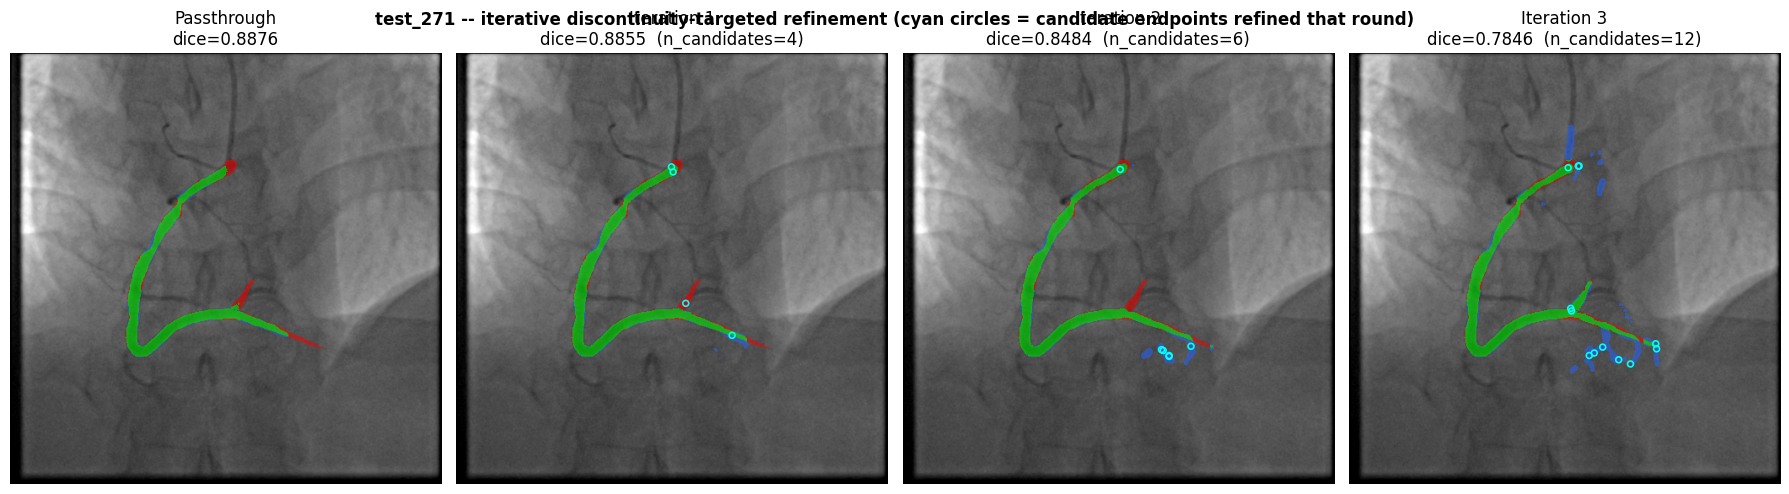

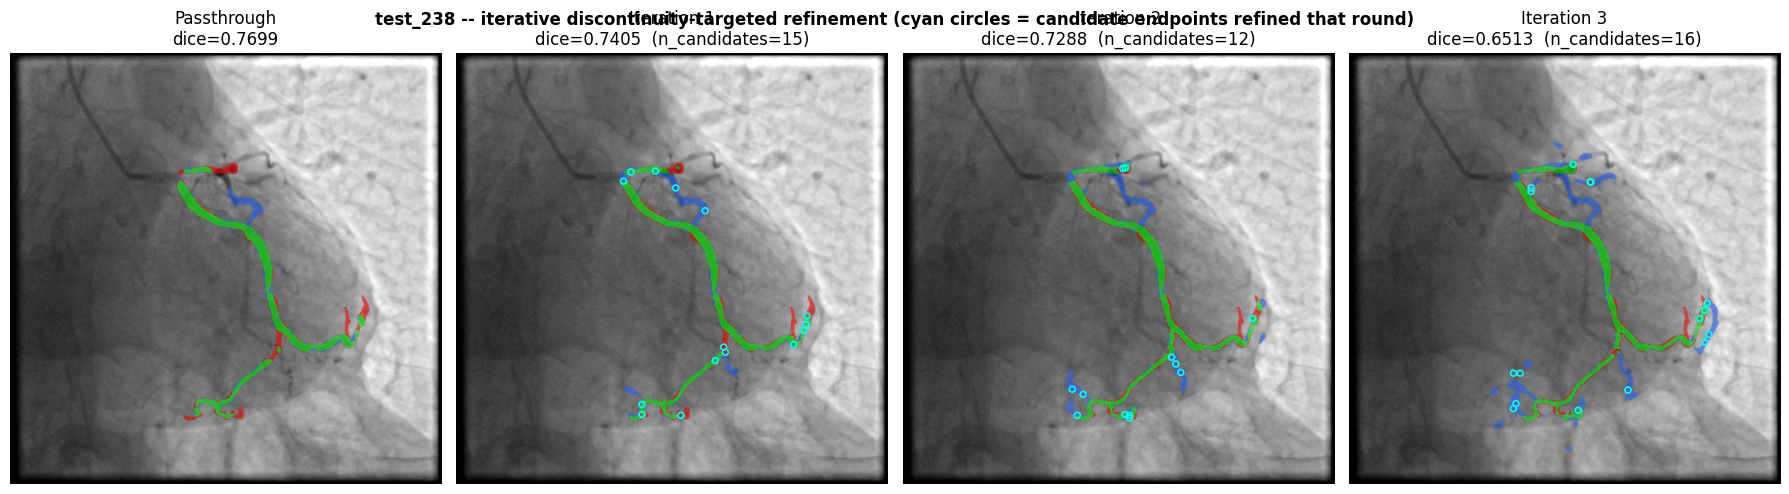

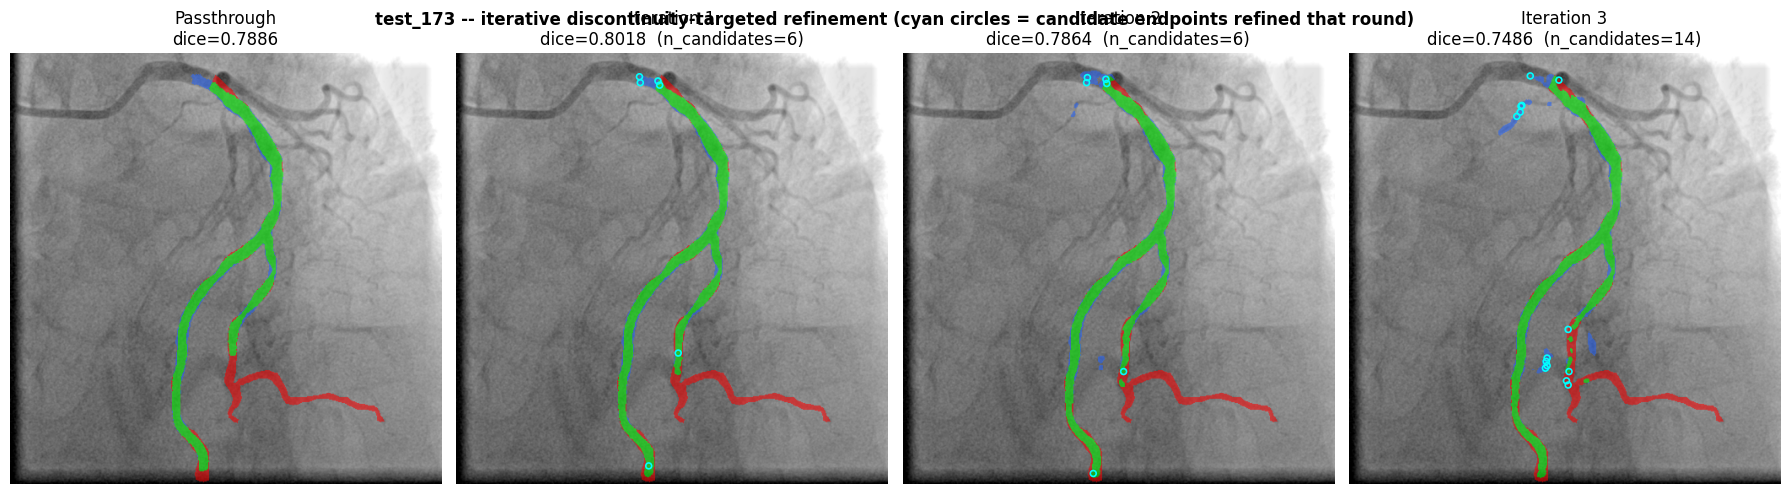

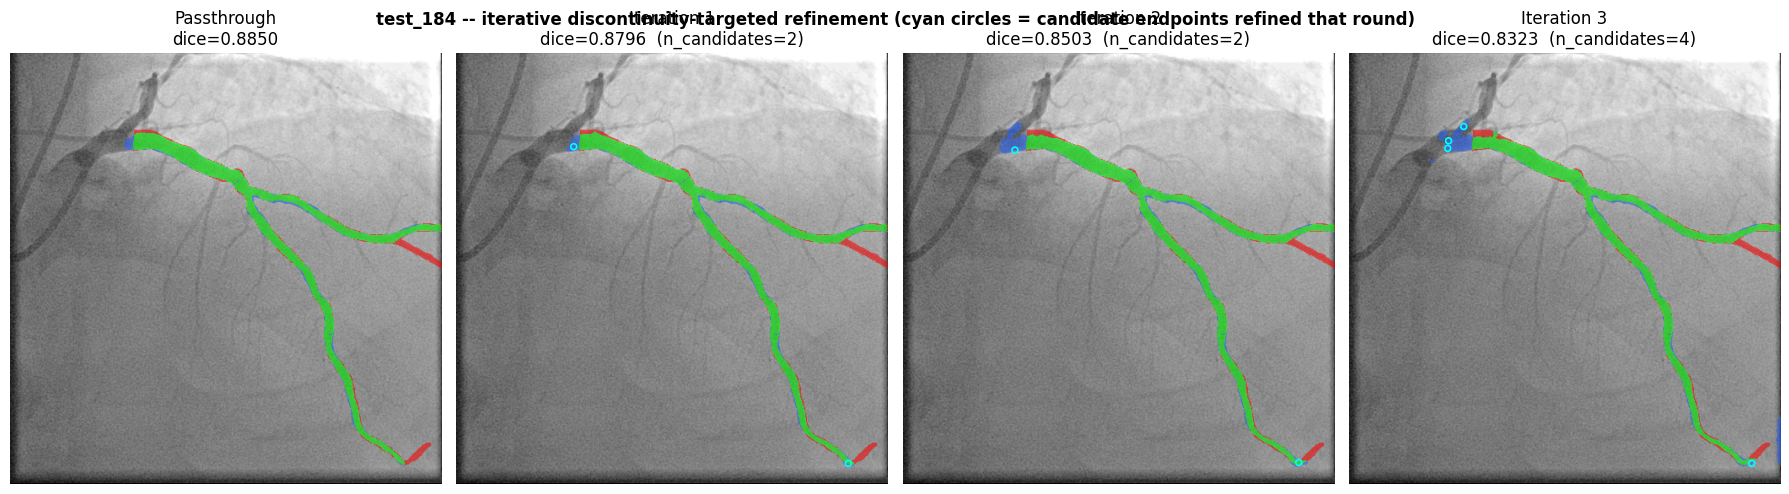

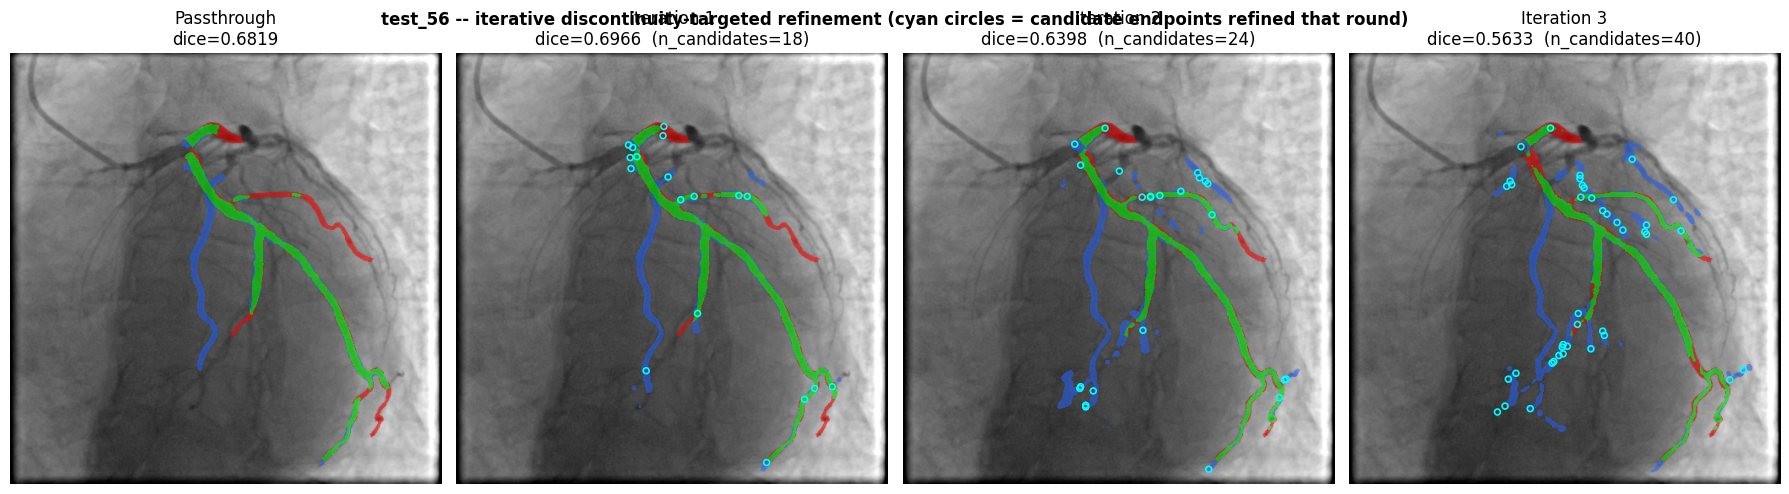

In [8]:
for icase in iterative_cases:
    raw, gt = icase["raw"], icase["gt"]
    history = icase["history"]
    n_cols = 1 + len(history)  # passthrough + each iteration

    fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 5))

    initial_prob = next(c["vessel_prob"] for c in cases if c["case_id"] == icase["case_id"])
    passthrough_pred = initial_prob > THRESHOLD
    axes[0].imshow(make_overlay(raw, gt, passthrough_pred))
    axes[0].set_title(f"Passthrough\ndice={dice_score(gt, passthrough_pred):.4f}")
    axes[0].axis("off")

    for col, h in enumerate(history, start=1):
        ax = axes[col]
        ax.imshow(make_overlay(raw, gt, h["binary_pred"]))
        if h["candidates"]:
            ys, xs = zip(*h["candidates"])
            ax.scatter(xs, ys, s=18, facecolors="none", edgecolors="cyan", linewidths=1.2)
        d = dice_score(gt, h["binary_pred"])
        ax.set_title(f"Iteration {h['iteration']}\ndice={d:.4f}  (n_candidates={h['n_candidates']})")
        ax.axis("off")

    fig.suptitle(f"{icase['case_id']} -- iterative discontinuity-targeted refinement "
                 f"(cyan circles = candidate endpoints refined that round)", fontweight="bold")
    plt.tight_layout()
    fig.savefig(METRICS_DIR / f"{icase['case_id']}_iterative_panel.png", dpi=130, bbox_inches="tight")
    plt.show()